# Supermarket Sales Analysis
## Notebook 04 - Dashboard Visual

**Objetivo:** Consolidar os principais insights em um único painel visual.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/supermarket_clean.csv', parse_dates=['Date'])

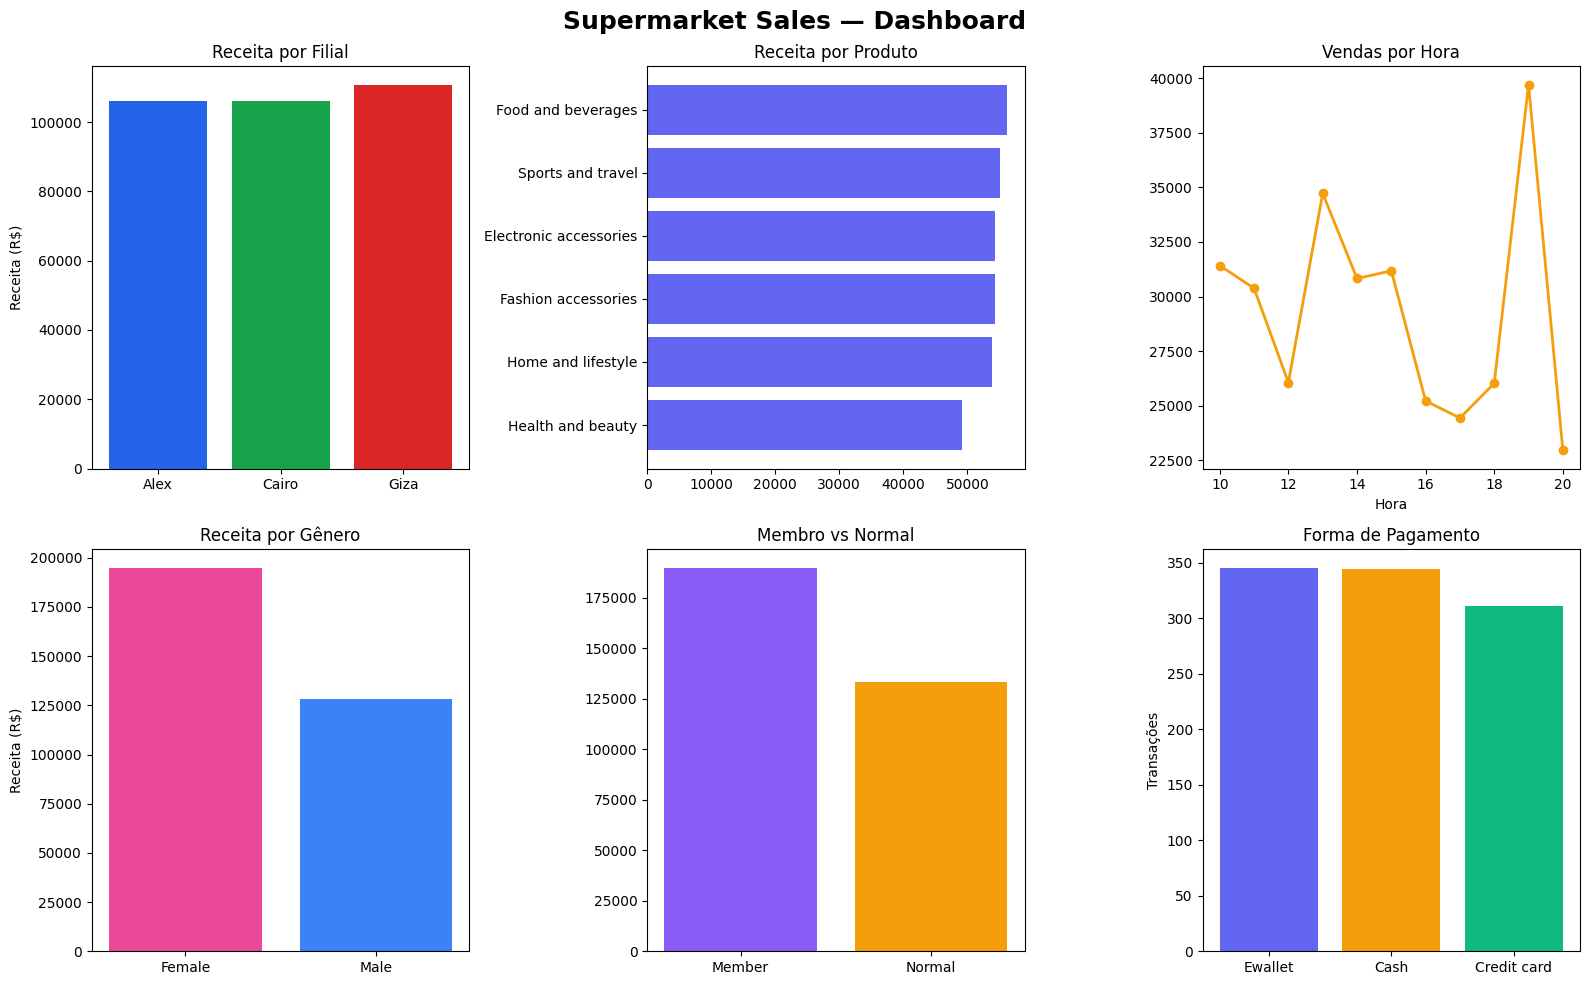

Dashboard salvo em data/dashboard.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Supermarket Sales — Dashboard', fontsize=18, fontweight='bold')

# Gráfico 1: Receita por Filial

receita_filial = df.groupby('Branch')['Sales'].sum()
axes[0, 0].bar(receita_filial.index, receita_filial.values, 
               color=['#2563EB', '#16A34A', '#DC2626'])
axes[0, 0].set_title('Receita por Filial')
axes[0, 0].set_ylabel('Receita (R$)')

# Gráfico 2: Receita por Produto

receita_produto = df.groupby('Product line')['Sales'].sum().sort_values()
axes[0, 1].barh(receita_produto.index, receita_produto.values, color='#6366F1')
axes[0, 1].set_title('Receita por Produto')

# Gráfico 3: Vendas por Hora

vendas_hora = df.groupby('hour')['Sales'].sum()
axes[0, 2].plot(vendas_hora.index, vendas_hora.values, 
                marker='o', color='#F59E0B', linewidth=2)
axes[0, 2].set_title('Vendas por Hora')
axes[0, 2].set_xlabel('Hora')

# Gráfico 4: Receita por Gênero

receita_genero = df.groupby('Gender')['Sales'].sum()
axes[1, 0].bar(receita_genero.index, receita_genero.values,
               color=['#EC4899', '#3B82F6'])
axes[1, 0].set_title('Receita por Gênero')
axes[1, 0].set_ylabel('Receita (R$)')

# Gráfico 5: Tipo de Cliente

tipo_cliente = df.groupby('Customer type')['Sales'].sum()
axes[1, 1].bar(tipo_cliente.index, tipo_cliente.values,
               color=['#8B5CF6', '#F59E0B'])
axes[1, 1].set_title('Membro vs Normal')

# Gráfico 6: Forma de Pagamento

pagamento = df['Payment'].value_counts()
axes[1, 2].bar(pagamento.index, pagamento.values,
               color=['#6366F1', '#F59E0B', '#10B981'])
axes[1, 2].set_title('Forma de Pagamento')
axes[1, 2].set_ylabel('Transações')

plt.tight_layout()
plt.savefig('../data/dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print('Dashboard salvo em data/dashboard.png')